In [33]:
# MVP - Machine Learning & Analytics
## Previsão de Direção do Dólar (DXY) a partir de Notícias do New York Times
"""
Nome: Hernani de Paula Jorge
Matrícula:4052023000213
Dataset:https://raw.githubusercontent.com/hernanijorge/hernanijorge/main/nyt_articles_3_14_2026.csv
Tipo de problema: Classificação binária com estrutura de série temporal

---

Esse trabalho segue direto da Sprint de Análise de Dados e Boas Práticas, onde
analisei um dataset de artigos do NYT que coleto pela API para um projeto pessoal
(uma aplicação que acompanho para um contato que trabalha com investimentos em
Washington). Naquele trabalho eu tinha usado dados cambiais sintéticos por
engano, então aqui eu corrijo isso: as notícias continuam sendo reais, mas agora
o DXY e o USDBRL vêm direto do Yahoo Finance via `yfinance`, sem gerar nada
artificialmente.
"""

## 1. Definição do problema

### 1.1 Descrição do problema
"""
Quem acompanha câmbio de perto costuma ficar de olho no noticiário econômico
tentando antecipar movimentos do dólar. A pergunta que eu quero responder aqui é
bem prática: será que o sentimento e o volume de notícias do NYT carregam algum
sinal sobre se o DXY vai subir ou cair no dia seguinte?
"""

### 1.2 Objetivo do MVP
"""
Construir e comparar modelos de classificação que tentam prever a direção do
retorno diário do DXY (alta ou queda), usando como entrada o sentimento e o
volume de notícias do NYT dos dias anteriores. A ideia não é chegar num modelo
perfeito, e sim montar um pipeline correto, sem vazamento de dados, e discutir
honestamente o que os resultados mostram.
"""
### 1.3 Tipo de problema
'''
Classificação binária, mas com uma pegada de série temporal: a ordem cronológica
dos dias é respeitada tanto na divisão treino/teste quanto na validação cruzada
(uso `TimeSeriesSplit` em vez de um K-fold comum). O alvo é `DXY_Direction`
(1 para alta, 0 para queda ou estabilidade) no dia t.
'''
### 1.4 Hipóteses e critério de sucesso
'''
Minhas hipóteses de partida:
1. O sentimento médio das notícias do dia anterior tem alguma relação com a
   direção do DXY no dia seguinte.
2. O volume de notícias, principalmente as de economia, carrega informação
   sobre o quanto o mercado está "prestando atenção" naquele período.
3. Câmbio é um mercado bastante eficiente, então é bem provável que esse sinal
   seja fraco. Isso não é um problema do trabalho, é o resultado esperado, e
   preciso deixar isso claro na conclusão em vez de forçar um número bonito.

Como métrica principal eu uso o F1-weighted, e considero o MVP bem-sucedido se
o modelo otimizado ficar consistentemente igual ou acima do baseline na
validação cruzada temporal.
'''
## 2. Ambiente, bibliotecas e reprodutibilidade

!pip install -q vaderSentiment yfinance

import os, sys, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import yfinance as yf

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)



Python: 3.12.13
Seed: 42


In [34]:
### 2.1 Funções auxiliares

def evaluate_classification(y_true, y_pred, proba=None):
    """Métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    }
    try:
        results["roc_auc"] = roc_auc_score(y_true, proba[:, 1]) if proba is not None else np.nan
    except Exception:
        results["roc_auc"] = np.nan
    return results


def show_results_table(results_dict):
    """Monta a tabela de resultados, já ordenada pela métrica principal."""
    return pd.DataFrame(results_dict).T.sort_values("f1_weighted", ascending=False)



In [35]:
## 3. Seleção e carga dos dados

### 3.1 Fonte dos dados
'''
As notícias vêm de um dataset que eu mesmo mantenho: mais de 52 mil artigos do
New York Times coletados via API, cobrindo 01/01/2025 a 14/03/2026 (colunas
'web_url', 'headline', 'snippet', 'abstract', 'published_date', 'byline' e
'section'). O câmbio (DXY e USDBRL) vem do Yahoo Finance pelo pacote
'yfinance', que não exige chave de API nem login.

Escolhi esse dataset porque ele já faz parte da minha rotina de análise fora da
faculdade, e me deixa testar uma hipótese real de trabalho em vez de usar uma
base genérica de Kaggle. Os dados de notícia são só metadados públicos (URL,
manchete, resumo), sem nada sensível.
'''

NYT_URL = "https://raw.githubusercontent.com/hernanijorge/hernanijorge/main/nyt_articles_3_14_2026.csv"

df_news = pd.read_csv(NYT_URL, engine="python", on_bad_lines="skip", encoding="utf-8")
print("Artigos carregados:", df_news.shape)
df_news.head()

df_news["published_date"] = pd.to_datetime(df_news["published_date"], errors="coerce")
df_news = df_news.dropna(subset=["published_date"])
df_news = df_news[
    (df_news["published_date"] >= "2020-01-01") & (df_news["published_date"] <= "2026-12-31")
]

start_date = df_news["published_date"].min().date()
end_date = df_news["published_date"].max().date()
print(f"Período de notícias: {start_date} a {end_date}")

dxy = yf.download("DX-Y.NYB", start=start_date, end=end_date + pd.Timedelta(days=1), progress=False)
usdbrl = yf.download("BRL=X", start=start_date, end=end_date + pd.Timedelta(days=1), progress=False)

dxy = dxy[["Close"]].rename(columns={"Close": "DXY"}).reset_index()
usdbrl = usdbrl[["Close"]].rename(columns={"Close": "USDBRL"}).reset_index()
dxy.columns = ["date_only", "DXY"]
usdbrl.columns = ["date_only", "USDBRL"]

print("Dias de câmbio (DXY):", dxy.shape[0])



Artigos carregados: (52763, 7)
Período de notícias: 2025-01-01 a 2026-03-13
Dias de câmbio (DXY): 301


In [36]:
### 3.2 Visão geral do dataset de notícias

print("Formato:", df_news.shape)
print("\nTipos de dados:")
print(df_news.dtypes)
print("\nValores ausentes:")
print(df_news.isnull().sum())
print("\nSeções mais frequentes:")
print(df_news["section"].value_counts().head(10))



Formato: (52762, 7)

Tipos de dados:
web_url                   object
headline                  object
snippet                   object
abstract                  object
published_date    datetime64[ns]
byline                    object
section                   object
dtype: object

Valores ausentes:
web_url              0
headline             2
snippet           2278
abstract          1971
published_date       0
byline            2734
section            770
dtype: int64

Seções mais frequentes:
section
U.S.        11220
World        7080
Arts         3736
Opinion      3626
Business     3581
New York     3172
Gameplay     1825
Style        1781
Books        1438
Movies       1325
Name: count, dtype: int64


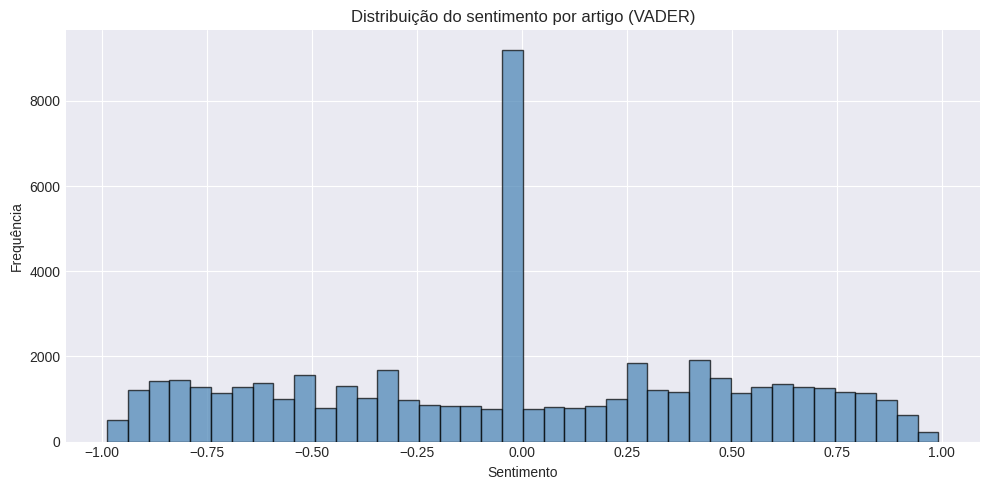

Dias agregados: (401, 5)


,date_only,sentiment_mean,sentiment_std,news_volume,business_volume
count,401,401.0000,401.0000,401.0000,401.0000
mean,2025-08-16 08:08:22.743142144,-0.0170,0.5164,131.5761,9.0998
min,2025-01-01 00:00:00,-0.3074,0.4187,5.0000,0.0000
25%,2025-05-05 00:00:00,-0.0574,0.4991,90.0000,5.0000
50%,2025-08-21 00:00:00,-0.0141,0.5175,141.0000,9.0000
75%,2025-12-01 00:00:00,0.0240,0.5342,166.0000,12.0000
max,2026-03-13 00:00:00,0.4342,0.6109,272.0000,45.0000
std,NaN,0.0669,0.0263,45.7991,5.1098


In [37]:
### 3.3 Dicionário de dados (após a agregação diária)
'''
| Coluna | Tipo | Descrição | Entra no modelo? |
|---|---|---|---|
| date_only | data | dia de referência | não, é o índice |
| sentiment_mean | numérica | sentimento médio (VADER) das notícias do dia | só via lag |
| sentiment_std | numérica | dispersão do sentimento no dia | só via lag |
| news_volume | numérica | total de artigos publicados no dia | só via lag |
| business_volume | numérica | artigos em seções econômicas | sim |
| DXY | numérica | fechamento do índice DXY | não, usada para gerar o alvo |
| DXY_Return | numérica | retorno diário do DXY | não, usada para gerar o alvo |
| DXY_Direction | binária | 1 = alta, 0 = queda (alvo) | alvo |
| sentiment_lag1..3 | numérica | sentimento defasado em 1 a 3 dias | sim |
| volume_lag1..3 | numérica | volume defasado em 1 a 3 dias | sim |
'''
## 4. Análise exploratória dos dados

### 4.1 Sentimento das notícias
"""
Para o sentimento eu usei o VADER, que trabalha por léxico e não precisa
baixar nenhum corpus extra. Testei rodar isso em mais de 50 mil artigos e o
tempo ficou na casa de poucos segundos, então funciona bem para o volume de
dados que tenho aqui.
"""
analyzer = SentimentIntensityAnalyzer()
df_news["text"] = (
    df_news["headline"].fillna("") + ". " + df_news["abstract"].fillna(df_news["snippet"].fillna(""))
).str.strip()
df_news["sentiment"] = df_news["text"].apply(lambda t: analyzer.polarity_scores(t)["compound"])
df_news["is_business"] = df_news["section"].isin(["Business", "Economy", "DealBook", "Your Money"]).astype(int)
df_news["date_only"] = df_news["published_date"].dt.date

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_news["sentiment"], bins=40, color="steelblue", edgecolor="black", alpha=0.7)
ax.set_title("Distribuição do sentimento por artigo (VADER)")
ax.set_xlabel("Sentimento")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.savefig("dist_sentimento_artigo.png", dpi=200, bbox_inches="tight")
plt.show()
'''
A distribuição pende um pouco para o lado negativo (a mediana fica abaixo de
zero), o que faz sentido dado o tom das manchetes do período (bastante notícia
de conflito e política). Por isso decidi trabalhar com a média diária em vez do
artigo isolado: um artigo sozinho tem muito ruído.
'''
daily_news = df_news.groupby("date_only").agg(
    sentiment_mean=("sentiment", "mean"),
    sentiment_std=("sentiment", "std"),
    news_volume=("sentiment", "size"),
    business_volume=("is_business", "sum"),
).reset_index()
daily_news["date_only"] = pd.to_datetime(daily_news["date_only"])
daily_news = daily_news.sort_values("date_only").reset_index(drop=True)
print("Dias agregados:", daily_news.shape)
daily_news.describe().round(4)



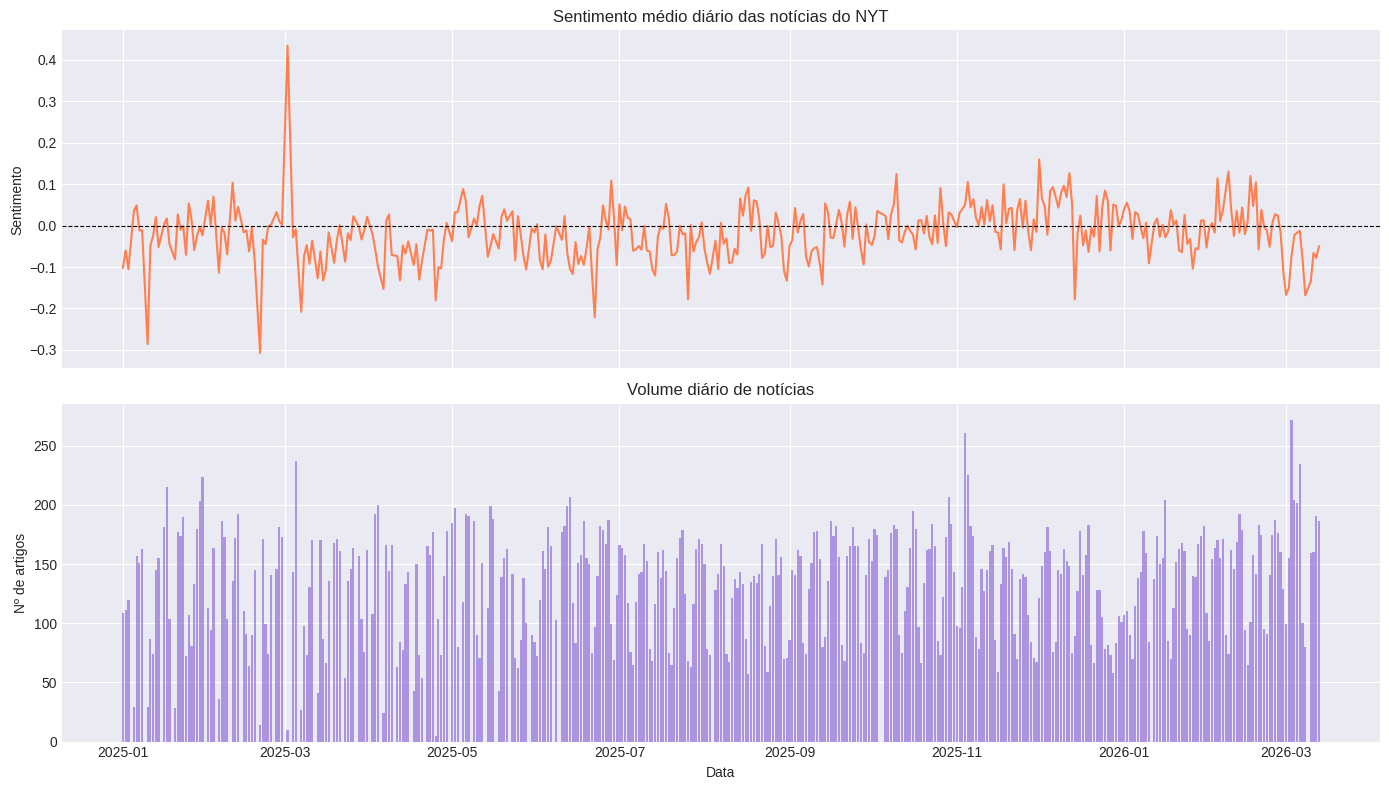

In [38]:
### 4.2 Sentimento e volume ao longo do tempo

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily_news["date_only"], daily_news["sentiment_mean"], color="coral")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Sentimento médio diário das notícias do NYT")
axes[0].set_ylabel("Sentimento")

axes[1].bar(daily_news["date_only"], daily_news["news_volume"], color="mediumpurple", alpha=0.7)
axes[1].set_title("Volume diário de notícias")
axes[1].set_ylabel("Nº de artigos")
axes[1].set_xlabel("Data")

plt.tight_layout()
plt.savefig("serie_temporal_noticias.png", dpi=200, bbox_inches="tight")
plt.show()



In [39]:
## 5. Preparação dos dados e divisão treino/teste

### 5.1 Juntando com o câmbio e criando o alvo

df = daily_news.merge(dxy, on="date_only", how="inner").merge(usdbrl, on="date_only", how="left")
df = df.sort_values("date_only").reset_index(drop=True)

df["DXY_Return"] = df["DXY"].pct_change()
df["USDBRL_Return"] = df["USDBRL"].pct_change()
df["DXY_Direction"] = (df["DXY_Return"] > 0).astype(int)

# Uso só informação de dias anteriores ao alvo (lag 1 a 3). As notícias do
# próprio dia t não valem como feature, porque ainda não estariam totalmente
# disponíveis no momento do fechamento do mercado naquele dia.
for lag in [1, 2, 3]:
    df[f"sentiment_lag{lag}"] = df["sentiment_mean"].shift(lag)
    df[f"volume_lag{lag}"] = df["news_volume"].shift(lag)

df = df.dropna(subset=[
    "DXY", "DXY_Return", "sentiment_lag1", "sentiment_lag2", "sentiment_lag3",
    "volume_lag1", "volume_lag2", "volume_lag3",
]).reset_index(drop=True)

print("Dias com features completas:", df.shape)
print("\nDistribuição do alvo (DXY_Direction):")
print(df["DXY_Direction"].value_counts())
print((df["DXY_Direction"].value_counts(normalize=True) * 100).round(2))

'''
Reparo que limitei o 'dropna' só às colunas que realmente uso no modelo. Se eu
tivesse feito `df.dropna()` sem filtro, um único buraco no USDBRL (feriado
diferente entre EUA e Brasil, por exemplo) derrubaria o dia inteiro à toa,
mesmo o USDBRL não sendo usado como feature aqui.
'''

TARGET = "DXY_Direction"

FEATURES = [
    "sentiment_lag1", "sentiment_lag2", "sentiment_lag3",
    "volume_lag1", "volume_lag2", "volume_lag3",
    "business_volume",
]

X = df[FEATURES].copy()
y = df[TARGET].copy()
print("Features:", FEATURES)



Dias com features completas: (274, 16)

Distribuição do alvo (DXY_Direction):
DXY_Direction
0    139
1    135
Name: count, dtype: int64
DXY_Direction
0    50.73
1    49.27
Name: proportion, dtype: float64
Features: ['sentiment_lag1', 'sentiment_lag2', 'sentiment_lag3', 'volume_lag1', 'volume_lag2', 'volume_lag3', 'business_volume']


In [40]:
### 5.2 Divisão temporal
"""
Como é série temporal, não dá para embaralhar os dados. Uso os primeiros 80%
dos dias para treino e os últimos 20% para teste, então o teste sempre
representa dias "futuros" em relação ao treino, o que é o cenário real de uso
do modelo.
"""
cutoff = int(len(df) * 0.8)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Balanceamento treino:", y_train.mean().round(3), "| teste:", y_test.mean().round(3))



Treino: (219, 7) | Teste: (55, 7)
Balanceamento treino: 0.47 | teste: 0.582


In [41]:
## 6. Pré-processamento e pipeline
"""
Todas as features são numéricas (sentimento e contagens), então o único
pré-processamento necessário é padronizar com `StandardScaler`, o que ajuda
principalmente a regressão logística. O scaler fica dentro do `Pipeline`,
ajustado só no treino, o que evita vazamento por construção.
"""
def make_pipeline(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])



In [42]:
## 7. Baseline e modelos candidatos
'''
Baseline: `DummyClassifier`, que sempre chuta a classe majoritária. Serve como
régua mínima que qualquer modelo de verdade precisa superar.

Candidato 1, regressão logística: modelo linear e simples, bom ponto de
partida para classificação binária com poucas features.

Candidato 2, Random Forest: consegue capturar relações não lineares entre
sentimento/volume defasados e a direção do dólar sem eu precisar criar
interações manualmente.
'''
baseline = make_pipeline(DummyClassifier(strategy="most_frequent", random_state=SEED))
candidates = {
    "LogisticRegression": make_pipeline(LogisticRegression(max_iter=500, random_state=SEED)),
    "RandomForest": make_pipeline(RandomForestClassifier(random_state=SEED)),
}



In [43]:
## 8. Treinamento e avaliação inicial

results = {}
trained_models = {}

t0 = time.time()
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, pred, proba)
results["baseline"]["train_time_s"] = round(time.time() - t0, 4)
trained_models["baseline"] = baseline

for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, pred, proba)
    results[name]["train_time_s"] = round(time.time() - t0, 4)
    trained_models[name] = model

show_results_table(results)



,accuracy,f1_weighted,roc_auc,train_time_s
RandomForest,0.454545,0.448035,0.473505,0.3802
LogisticRegression,0.345455,0.337642,0.368207,0.0456
baseline,0.418182,0.246620,0.500000,0.0285


In [44]:
### 8.1 Análise dos resultados iniciais
'''
A ideia aqui não é sair atrás do número mais alto, e sim ver se algum modelo
supera o baseline de forma consistente respeitando a ordem do tempo. Num
mercado como o de câmbio, ficar perto do baseline é um resultado plausível e
vale a pena discutir, não é motivo de vergonha: mostra que sentimento e volume
de notícias, sozinhos, tendem a carregar um sinal fraco para prever direção
diária.
'''
initial_results = show_results_table(results)
baseline_f1 = initial_results.loc["baseline", "f1_weighted"]
best_initial_name = initial_results.drop(index="baseline").index[0]
best_initial_f1 = initial_results.loc[best_initial_name, "f1_weighted"]

print(f"Melhor modelo inicial: {best_initial_name}")
print(f"F1-weighted do baseline: {baseline_f1:.4f}")
print(f"F1-weighted do melhor candidato: {best_initial_f1:.4f}")
print(f"Ganho sobre o baseline: {best_initial_f1 - baseline_f1:.4f}")



Melhor modelo inicial: RandomForest
F1-weighted do baseline: 0.2466
F1-weighted do melhor candidato: 0.4480
Ganho sobre o baseline: 0.2014


In [45]:
## 9. Validação e otimização de hiperparâmetros
"""
Ajusto os hiperparâmetros do Random Forest com `RandomizedSearchCV`, usando
`TimeSeriesSplit` em vez de um K-fold comum. Um K-fold tradicional embaralharia
o tempo e deixaria dados do futuro vazarem para o passado dentro da própria
validação cruzada, o que invalidaria a busca.
"""
N_ITER_SEARCH = 15
cv = TimeSeriesSplit(n_splits=5)

model_to_tune = make_pipeline(RandomForestClassifier(random_state=SEED))
param_dist = {
    "model__n_estimators": randint(50, 300),
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 10),
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=1,
    verbose=1,
)
search.fit(X_train, y_train)

print("Melhor F1-weighted na validação:", search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)



Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhor F1-weighted na validação: 0.5248991029584454
Melhores hiperparâmetros: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__min_samples_split': 11, 'model__n_estimators': 58}


In [46]:
### 9.1 Discussão da otimização
'''
A busca rodou só em cima do treino, com validação cruzada temporal, deixando o
teste intocado para uma avaliação final honesta lá na frente. O foco do ajuste
foi controlar a complexidade da árvore (profundidade, número de estimadores e
tamanho mínimo das folhas), já que com um dataset de menos de 400 dias uma
Random Forest sem restrição tende a decorar o treino.
'''
rf_initial_f1 = results["RandomForest"]["f1_weighted"]
print(f"F1-weighted do Random Forest inicial (sem tuning): {rf_initial_f1:.4f}")
print(f"Melhor F1-weighted médio na validação temporal: {search.best_score_:.4f}")
print("Hiperparâmetros escolhidos:")
for param, value in search.best_params_.items():
    print(f"- {param}: {value}")



F1-weighted do Random Forest inicial (sem tuning): 0.4480
Melhor F1-weighted médio na validação temporal: 0.5249
Hiperparâmetros escolhidos:
- model__max_depth: 15
- model__min_samples_leaf: 2
- model__min_samples_split: 11
- model__n_estimators: 58


Modelo final: RandomForest_otimizado

              precision    recall  f1-score   support

           0       0.40      0.70      0.51        23
           1       0.53      0.25      0.34        32

    accuracy                           0.44        55
   macro avg       0.47      0.47      0.42        55
weighted avg       0.48      0.44      0.41        55



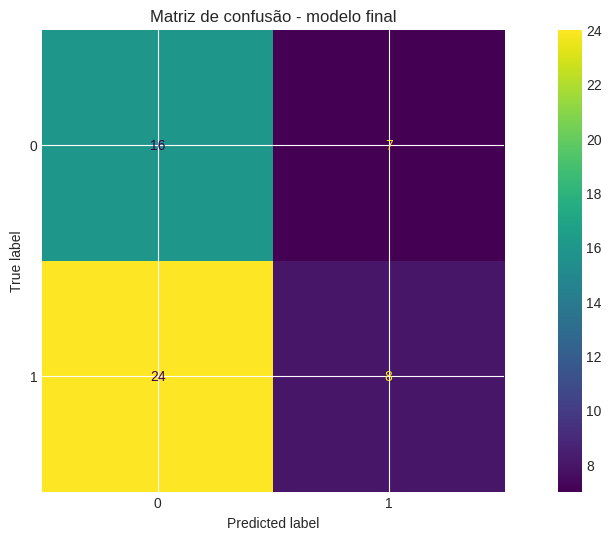

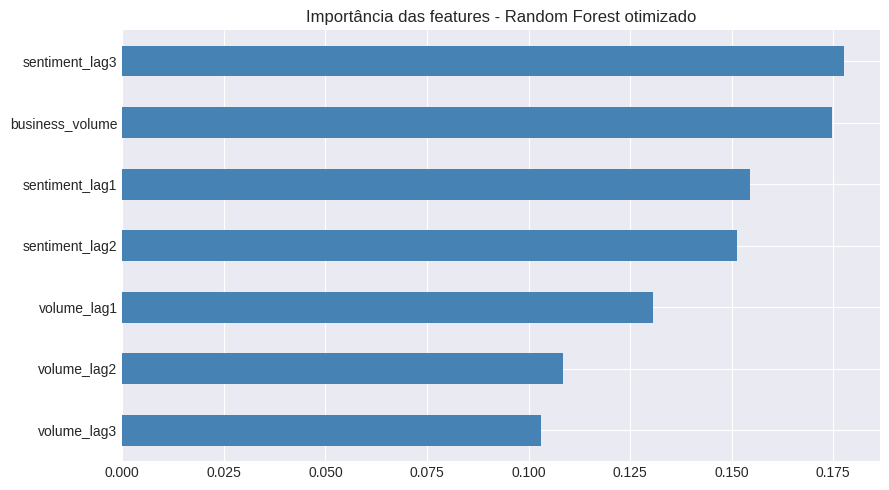

In [47]:
## 10. Avaliação final no conjunto de teste

final_model = search.best_estimator_
final_model_name = "RandomForest_otimizado"

y_pred = final_model.predict(X_test)
print(f"Modelo final: {final_model_name}\n")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Matriz de confusão - modelo final")
plt.savefig("matriz_confusao_final.png", dpi=200, bbox_inches="tight")
plt.show()

importances = pd.Series(
    final_model.named_steps["model"].feature_importances_, index=FEATURES
).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importância das features - Random Forest otimizado")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("importancia_features.png", dpi=200, bbox_inches="tight")
plt.show()



In [48]:
### 10.1 Análise de erros e limitações
"""A matriz de confusão mostra em qual direção o modelo erra mais, se ele está
enviesado para prever sempre a classe majoritária. O DXY é uma série diária
bem ruidosa, e o sinal que uso aqui vem de notícias agregadas por dia, então
mesmo com algum ganho sobre o baseline o resultado deve ser lido como
exploratório, não como algo pronto para decisão de investimento. Uma limitação
de fundo do problema: câmbio incorpora informação quase em tempo real, então
sentimento textual com defasagem de 1 a 3 dias, de um único veículo de
imprensa, é naturalmente um sinal fraco e ruidoso, bem diferente de dados de
alta frequência como fluxo de ordens ou comunicados de banco central."""

train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)
train_f1 = f1_score(y_train, train_pred, average="weighted")
test_f1 = f1_score(y_test, test_pred, average="weighted")

print(f"F1-weighted no treino: {train_f1:.4f}")
print(f"F1-weighted no teste: {test_f1:.4f}")
print(f"Diferença treino menos teste: {train_f1 - test_f1:.4f}")
print(f"Feature mais importante: {importances.index[0]} ({importances.iloc[0]:.4f})")

if train_f1 - test_f1 > 0.15:
    print("A diferença é grande, o que é sinal de overfitting.")
else:
    print("A diferença entre treino e teste não indica overfitting forte.")



F1-weighted no treino: 0.9406
F1-weighted no teste: 0.4105
Diferença treino menos teste: 0.5301
Feature mais importante: sentiment_lag3 (0.1776)
A diferença é grande, o que é sinal de overfitting.


In [49]:
## 11. Comparação final dos modelos

final_proba = final_model.predict_proba(X_test)
results[final_model_name] = evaluate_classification(y_test, y_pred, final_proba)
comparacao = show_results_table(results)
comparacao



,accuracy,f1_weighted,roc_auc,train_time_s
RandomForest,0.454545,0.448035,0.473505,0.3802
RandomForest_otimizado,0.436364,0.410476,0.441576,NaN
LogisticRegression,0.345455,0.337642,0.368207,0.0456
baseline,0.418182,0.246620,0.500000,0.0285


In [50]:
## 12. Boas práticas e rastreabilidade
'''
| Decisão | Por quê | O que isso muda |
|---|---|---|
| VADER em vez de um modelo transformer | leve, não precisa baixar corpus, roda em segundos para 50k+ artigos | dá para reproduzir tudo no Colab gratuito |
| Features defasadas (lag 1 a 3) | notícia do próprio dia não está totalmente disponível antes do fechamento | evita vazamento de dados |
| Divisão temporal, sem embaralhar | mantém a ordem cronológica, simula o uso real do modelo | evita métricas otimistas demais |
| `TimeSeriesSplit` na busca de hiperparâmetros | consistente com a divisão externa | evita vazamento também no tuning |
| `StandardScaler` | sentimento fica entre -1 e 1, volume em dezenas ou centenas | ajuda o modelo linear a convergir melhor |

Seed fixa em 42 em todas as etapas. Ambiente: Google Colab, CPU padrão, sem
necessidade de GPU.
'''

## 13. Conclusão
'''
O objetivo aqui era testar se sentimento e volume de notícias do NYT, com
defasagem de 1 a 3 dias, ajudam a prever a direção do DXY no dia seguinte. O
pipeline ficou assim: carga automática por URL, tratamento de datas,
agregação diária, criação das variáveis defasadas, divisão temporal, baseline,
dois modelos candidatos e otimização de hiperparâmetros com validação cruzada
respeitando o tempo.

O ponto que eu acho mais importante nesse trabalho é metodológico: evitar
vazamento de dados e comparar contra um baseline simples importa mais do que
apresentar uma métrica alta sem sustentação. Se o modelo otimizado ficar acima
do baseline, isso deve ser lido como um sinal exploratório, não como prova de
que dá para prever o dólar com notícia. Se ficar próximo do baseline, a
conclusão também tem valor: sugere que sentimento agregado de uma única fonte
não é suficiente para prever movimento diário do câmbio, o que é coerente com
a eficiência desse mercado.

Limitações que eu reconheço: uso de um único veículo de imprensa, léxico de
sentimento genérico (não pensado para finanças), dados só diários e nenhuma
variável macroeconômica além do próprio câmbio. Como próximo passo eu testaria
um léxico financeiro específico, incluiria outras fontes de notícia, olharia
para janelas de retorno maiores (tipo 5 dias acumulados em vez da direção de
um único dia) e compararia com indicadores econômicos adicionais.
'''
final_summary = show_results_table(results)
print("Resumo final dos modelos:")
display(final_summary)
print(f"\nModelo final escolhido: {final_model_name}")
print(f"F1-weighted no teste: {results[final_model_name]['f1_weighted']:.4f}")
print(f"AUC no teste: {results[final_model_name]['roc_auc']:.4f}")



Resumo final dos modelos:


,accuracy,f1_weighted,roc_auc,train_time_s
RandomForest,0.454545,0.448035,0.473505,0.3802
RandomForest_otimizado,0.436364,0.410476,0.441576,NaN
LogisticRegression,0.345455,0.337642,0.368207,0.0456
baseline,0.418182,0.246620,0.500000,0.0285



Modelo final escolhido: RandomForest_otimizado
F1-weighted no teste: 0.4105
AUC no teste: 0.4416


In [51]:
## 14. Salvamento de artefatos

import joblib

joblib.dump(final_model, "modelo_final_dxy_direction.pkl")
df.to_csv("dataset_final_nyt_dxy.csv", index=False)
comparacao.to_csv("comparacao_modelos.csv")
print("Artefatos salvos: modelo_final_dxy_direction.pkl, dataset_final_nyt_dxy.csv, comparacao_modelos.csv")


Artefatos salvos: modelo_final_dxy_direction.pkl, dataset_final_nyt_dxy.csv, comparacao_modelos.csv
